# Qwen Template Matching: Preprocess + Hybrid Only

This notebook tests only the two Qwen-based retrieval approaches:
- preprocess
- hybrid (image + OCR text)

It loads template pages from `templates/` and query pages from `test/`, then compares the retrieved template matches for each query image.

In [1]:
import numpy as np
import torch
import chromadb
from chromadb.config import Settings
from pathlib import Path
from PIL import Image, ImageOps, ImageEnhance
import pypdfium2 as pdfium
import matplotlib.pyplot as plt
from typing import Dict, List, Any
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

template_dir = Path('templates')
query_dir = Path('test')
supported_extensions = {'.pdf', '.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif', '.webp'}

modes = ['preprocess', 'hybrid']
top_k = 3
hybrid_alpha = 0.7

# ChromaDB storage for this notebook
chroma_root = Path('chroma_layout_db')
qwen_preprocess_dir = chroma_root / 'qwen_preprocess_only'
qwen_hybrid_dir = chroma_root / 'qwen_hybrid_only'
qwen_text_dir = chroma_root / 'qwen_text_only'
qwen_preprocess_dir.mkdir(parents=True, exist_ok=True)
qwen_hybrid_dir.mkdir(parents=True, exist_ok=True)
qwen_text_dir.mkdir(parents=True, exist_ok=True)

print(f'Modes: {modes}')


Using device: cuda
Modes: ['preprocess', 'hybrid']


In [2]:
from sentence_transformers import SentenceTransformer

print('=' * 60)
print('Loading Qwen3-VL-Embedding model...')
print('=' * 60)
qwen_model = SentenceTransformer('Qwen/Qwen3-VL-Embedding-2B')
print('Qwen3-VL-Embedding loaded successfully')
print('Embedding dimension: 2048')

Loading Qwen3-VL-Embedding model...


Loading weights: 100%|██████████| 625/625 [00:00<00:00, 3783.25it/s]
Default prompt name is set to 'default'. This prompt will be applied to all inference calls, except if a `prompt` or `prompt_name` parameter is provided.


Qwen3-VL-Embedding loaded successfully
Embedding dimension: 2048


In [10]:
# OCR setup
from pathlib import Path
from PIL import Image, ImageOps, ImageEnhance
import numpy as np
import pypdfium2 as pdfium
from typing import Dict, List, Any
from paddleocr import PaddleOCR
from PIL import Image, ImageOps
OCR_ENGINE = 'paddleocr'
import cv2

print(f'OCR engine: {OCR_ENGINE}')

# Using transformers engine with PP-OCRv6_medium models
ocr_reader = PaddleOCR(
    text_detection_model_name="PP-OCRv6_medium_det",
    text_recognition_model_name="PP-OCRv6_medium_rec",
    engine="transformers",
    device="gpu:0" if torch.cuda.is_available() else "cpu",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
)

def render_pdf_pages(pdf_path: Path, scale: float = 2.0) -> List[Image.Image]:
    document = pdfium.PdfDocument(str(pdf_path))
    return [page.render(scale=scale).to_pil().convert('RGB') for page in document]

def load_document_pages(file_path: Path) -> List[Image.Image]:
    suffix = file_path.suffix.lower()
    if suffix == '.pdf':
        return render_pdf_pages(file_path)
    if suffix in supported_extensions:
        return [Image.open(file_path).convert('RGB')]
    raise ValueError(f'Unsupported file type: {file_path}')

def build_image_records(folder: Path, source_type: str) -> List[Dict[str, Any]]:
    records: List[Dict[str, Any]] = []
    files = sorted(
        file_path for file_path in folder.iterdir()
        if file_path.is_file() and file_path.suffix.lower() in supported_extensions
    )
    for file_path in files:
        pages = load_document_pages(file_path)
        for page_number, image in enumerate(pages, start=1):
            page_suffix = f'_page_{page_number}' if len(pages) > 1 else ''
            records.append({
                'id': f'{source_type}_{file_path.stem}{page_suffix}',
                'name': f'{file_path.name}{page_suffix}',
                'image': image,
                'file_name': file_path.name,
                'file_path': str(file_path),
                'page_number': page_number,
                'source_type': source_type,
            })
            print(f'Loaded {source_type}: {file_path.name} (page {page_number})')
    return records



def preprocess_image(image: Image.Image, target_size=(896, 896)) -> Image.Image:
    # 1. Convert PIL to OpenCV Grayscale to handle contrast smartly
    img_np = np.array(image.convert('L'))
    
    # 2. Apply CLAHE (Adaptive Contrast) instead of global contrast enhancement
    # This enhances faint lines/text locally without destroying the whole layout
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_np = clahe.apply(img_np)
    
    # 3. Convert back to PIL RGB (VLM requirement)
    enhanced_img = Image.fromarray(enhanced_np).convert('RGB')
    
    # 4. Resize preserving aspect ratio (No cropping)
    enhanced_img.thumbnail(target_size, Image.Resampling.LANCZOS)
    
    # 5. Dynamic Padding: Match the background of your actual document
    # Using white (255) is usually safer for documents than neutral gray
    bg_color = (255, 255, 255) 
    new_img = Image.new("RGB", target_size, bg_color)
    
    # Center the image
    x_offset = (target_size[0] - enhanced_img.size[0]) // 2
    y_offset = (target_size[1] - enhanced_img.size[1]) // 2
    new_img.paste(enhanced_img, (x_offset, y_offset))
    
    return new_img

def cosine_sim(vec_a: np.ndarray, vec_b: np.ndarray) -> float:
    denom = float(np.linalg.norm(vec_a) * np.linalg.norm(vec_b))
    if denom == 0.0:
        return 0.0
    return float(np.dot(vec_a, vec_b) / denom)

def extract_text(image: Image.Image) -> str:
    if OCR_ENGINE == 'paddleocr':
        try:
            result = ocr_reader.predict(np.array(image))
            chunks: List[str] = []
            for res in result:
                rec_texts = getattr(res, "rec_texts", None)
                if rec_texts is None and isinstance(res, dict):
                    rec_texts = res.get("rec_texts", [])
                if rec_texts:
                    chunks.extend([t for t in rec_texts if isinstance(t, str)])
            text = " ".join(" ".join(chunks).split())
            print(f"Extracted text: {text[:50]}...")
            return text
        except Exception:
            return ''
    return ''

def text_similarity(query_text: str, template_text: str) -> float:
    if qwen_model is not None and query_text and template_text:
        try:
            qv = qwen_model.encode(query_text)
            tv = qwen_model.encode(template_text)
            return cosine_sim(np.asarray(qv), np.asarray(tv))
        except Exception:
            pass

    q_tokens = set(query_text.lower().split())
    t_tokens = set(template_text.lower().split())
    if not q_tokens or not t_tokens:
        return 0.0
    inter = len(q_tokens.intersection(t_tokens))
    union = len(q_tokens.union(t_tokens))
    return float(inter / union) if union else 0.0

def embed_image_qwen(image: Image.Image) -> np.ndarray:
    return np.asarray(qwen_model.encode(image))


Creating model: ('PP-OCRv6_medium_det', None, 'transformers')
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/dellpromax/.paddlex/official_models/PP-OCRv6_medium_det_safetensors`.


OCR engine: paddleocr


Loading weights: 100%|██████████| 350/350 [00:00<00:00, 3941.63it/s]
Creating model: ('PP-OCRv6_medium_rec', None, 'transformers')
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/dellpromax/.paddlex/official_models/PP-OCRv6_medium_rec_safetensors`.
Loading weights: 100%|██████████| 269/269 [00:00<00:00, 3275.77it/s]


In [11]:
print('=' * 60)
print('Loading template and query documents...')
print('=' * 60)
template_records = build_image_records(template_dir, 'template')
query_records = build_image_records(query_dir, 'query')

if not template_records:
    raise RuntimeError('No template pages found in templates/.')
if not query_records:
    raise RuntimeError('No query pages found in test/.')

template_by_id = {record['id']: record for record in template_records}
query_by_id = {record['id']: record for record in query_records}

mode_template_embeddings = {mode: {} for mode in modes}
mode_query_embeddings = {mode: {} for mode in modes}
template_texts = {}
query_texts = {}

print('Building template caches...')
for rec in template_records:
    preprocessed = preprocess_image(rec['image'])
    emb = embed_image_qwen(preprocessed)
    for mode in modes:
        mode_template_embeddings[mode][rec['id']] = emb
    template_texts[rec['id']] = extract_text(preprocessed)

print('Building query caches...')
for rec in query_records:
    preprocessed = preprocess_image(rec['image'])
    emb = embed_image_qwen(preprocessed)
    for mode in modes:
        mode_query_embeddings[mode][rec['id']] = emb
    query_texts[rec['id']] = extract_text(preprocessed)

print('Resetting and rebuilding dedicated ChromaDB collections...')

pre_client = chromadb.PersistentClient(
    path=str(qwen_preprocess_dir),
    settings=Settings(allow_reset=True, anonymized_telemetry=False, is_persistent=True)
)
hyb_client = chromadb.PersistentClient(
    path=str(qwen_hybrid_dir),
    settings=Settings(allow_reset=True, anonymized_telemetry=False, is_persistent=True)
)

for client, name in [(pre_client, 'qwen_preprocess_images'), (hyb_client, 'qwen_hybrid_images')]:
    try:
        client.delete_collection(name=name)
    except Exception:
        print(f"Failed to delete collection {name}. It may not exist yet.")

pre_collection = pre_client.create_collection(
    name='qwen_preprocess_images',
    metadata={'hnsw:space': 'cosine'}
)
hyb_collection = hyb_client.create_collection(
    name='qwen_hybrid_images',
    metadata={'hnsw:space': 'cosine'}
)

for rec in template_records:
    t_id = rec['id']

    pre_collection.add(
        ids=[t_id],
        embeddings=[mode_template_embeddings['preprocess'][t_id].tolist()],
        metadatas=[{
            'file_name': rec['file_name'],
            'page_number': rec['page_number'],
            'file_path': rec['file_path'],
            'source_type': rec['source_type'],
            'mode': 'preprocess',
            'model': 'qwen3-vl-embedding-2b'
        }]
    )

    hyb_collection.add(
        ids=[t_id],
        embeddings=[mode_template_embeddings['hybrid'][t_id].tolist()],
        metadatas=[{
            'file_name': rec['file_name'],
            'page_number': rec['page_number'],
            'file_path': rec['file_path'],
            'source_type': rec['source_type'],
            'mode': 'hybrid',
            'model': 'qwen3-vl-embedding-2b'
        }]
    )

print(f"Preprocess collection size: {pre_collection.count()}")
print(f"Hybrid collection size: {hyb_collection.count()}")
print('Caches ready.')


Loading template and query documents...
Loaded template: CoO UN template.png (page 1)
Loaded template: CoO WCO (kyoto).png (page 1)
Loaded template: Egypt- CoO Templates.pdf (page 1)
Loaded template: Egypt- CoO Templates.pdf (page 2)
Loaded template: Egypt- CoO Templates.pdf (page 3)
Loaded template: Egypt- CoO Templates.pdf (page 4)
Loaded template: Egypt- CoO Templates.pdf (page 5)
Loaded template: Egypt- CoO Templates.pdf (page 6)
Loaded template: Egypt- CoO Templates.pdf (page 7)
Loaded template: Egypt- CoO Templates.pdf (page 8)
Loaded template: Egypt- CoO Templates.pdf (page 9)
Loaded template: Egypt- CoO Templates.pdf (page 10)
Loaded query: 10_GAFTA_Arabic.png (page 1)
Loaded query: 1_AfCFTA.png (page 1)
Loaded query: 2_COMESA.png (page 1)
Loaded query: 3_EUR1_MovementCertificate.png (page 1)
Loaded query: 4_EURMED_MovementCertificate.png (page 1)
Loaded query: 5_GSP_FormA.png (page 1)
Loaded query: 6_GSTP.png (page 1)
Loaded query: 7_Mercosur_Egypt.png (page 1)
Loaded query: 8

Query: 10_GAFTA_Arabic.png|1
  preprocess -> top1: Egypt- CoO Templates.pdf|10 | sim=0.7278
  preprocess -> top2: Egypt- CoO Templates.pdf|9 | sim=0.5748
  preprocess -> top3: Egypt- CoO Templates.pdf|5 | sim=0.5226
  hybrid     -> top1: Egypt- CoO Templates.pdf|10 | sim=0.7164
  hybrid     -> top2: Egypt- CoO Templates.pdf|9 | sim=0.5682
  hybrid     -> top3: Egypt- CoO Templates.pdf|3 | sim=0.5101
Query: 1_AfCFTA.png|1
  preprocess -> top1: Egypt- CoO Templates.pdf|1 | sim=0.6985
  preprocess -> top2: Egypt- CoO Templates.pdf|8 | sim=0.6466
  preprocess -> top3: Egypt- CoO Templates.pdf|5 | sim=0.5963
  hybrid     -> top1: Egypt- CoO Templates.pdf|1 | sim=0.7101
  hybrid     -> top2: Egypt- CoO Templates.pdf|8 | sim=0.6810
  hybrid     -> top3: Egypt- CoO Templates.pdf|7 | sim=0.6557
Query: 2_COMESA.png|1
  preprocess -> top1: Egypt- CoO Templates.pdf|2 | sim=0.8299
  preprocess -> top2: Egypt- CoO Templates.pdf|1 | sim=0.5992
  preprocess -> top3: Egypt- CoO Templates.pdf|7 | sim=0.

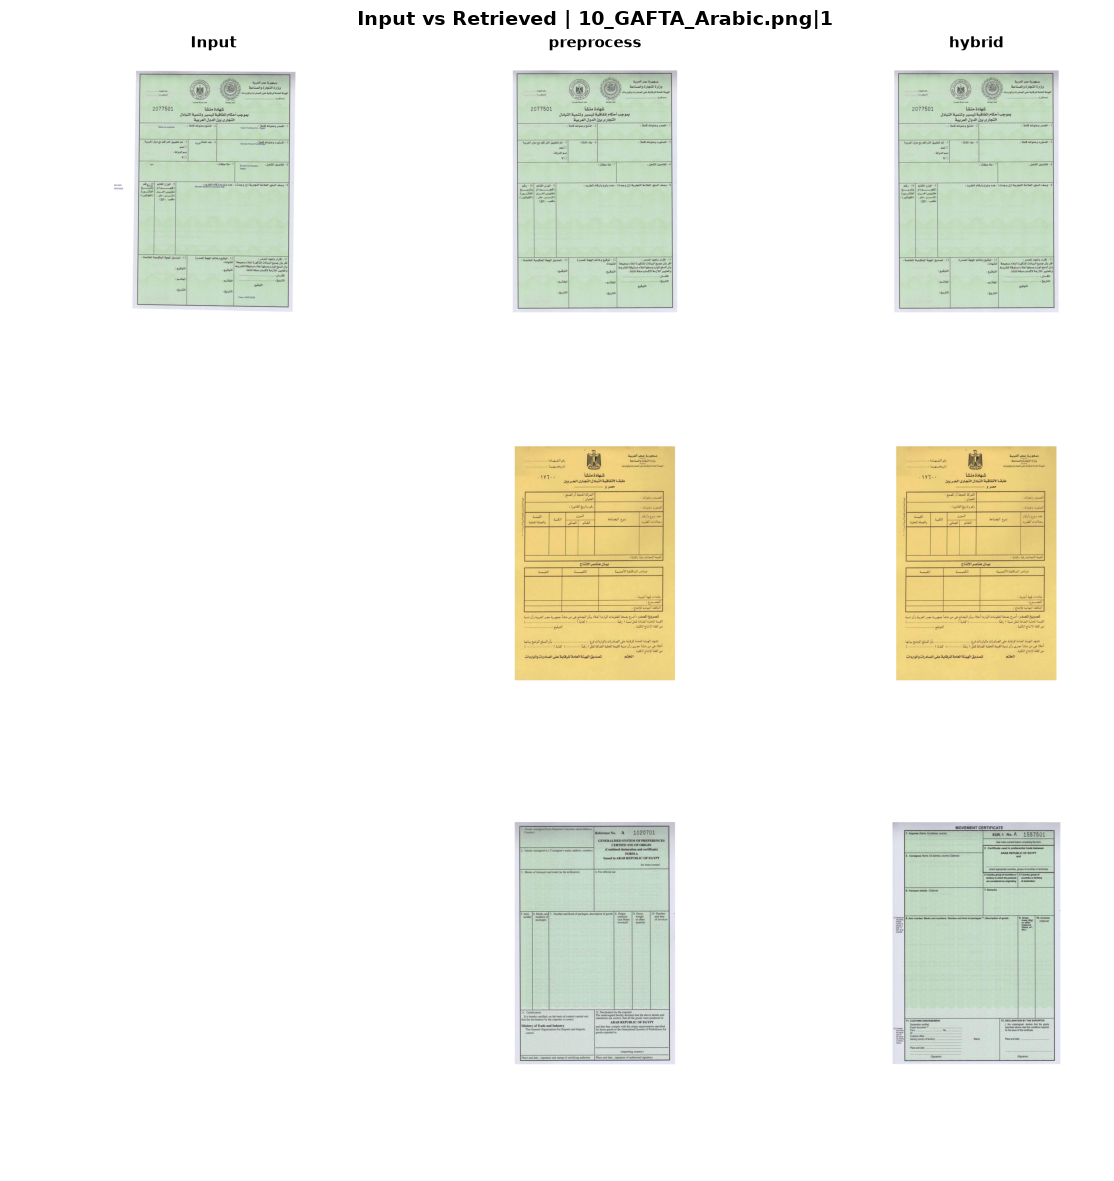

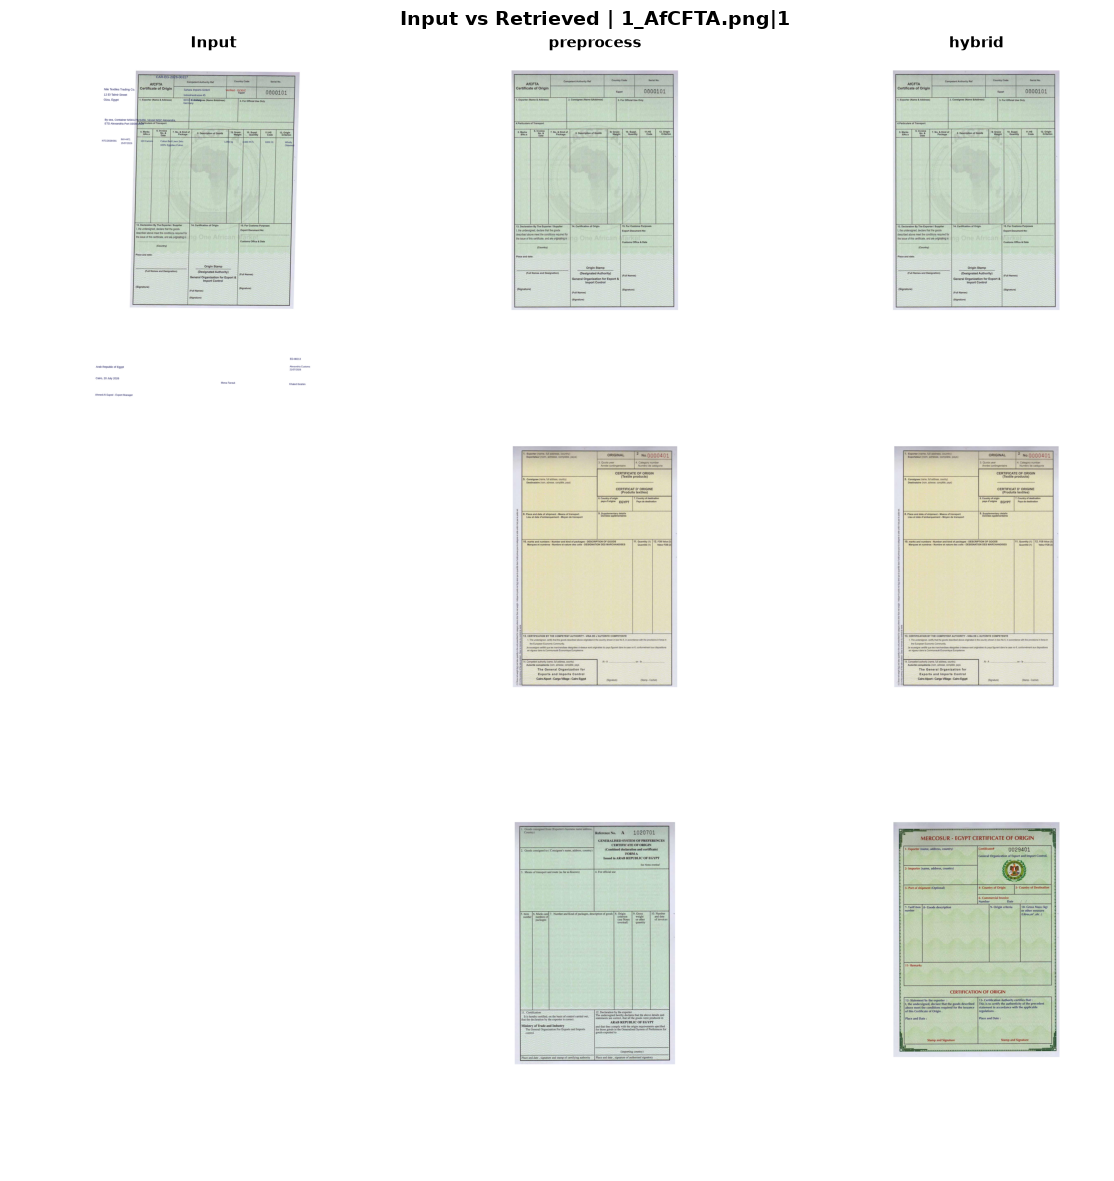

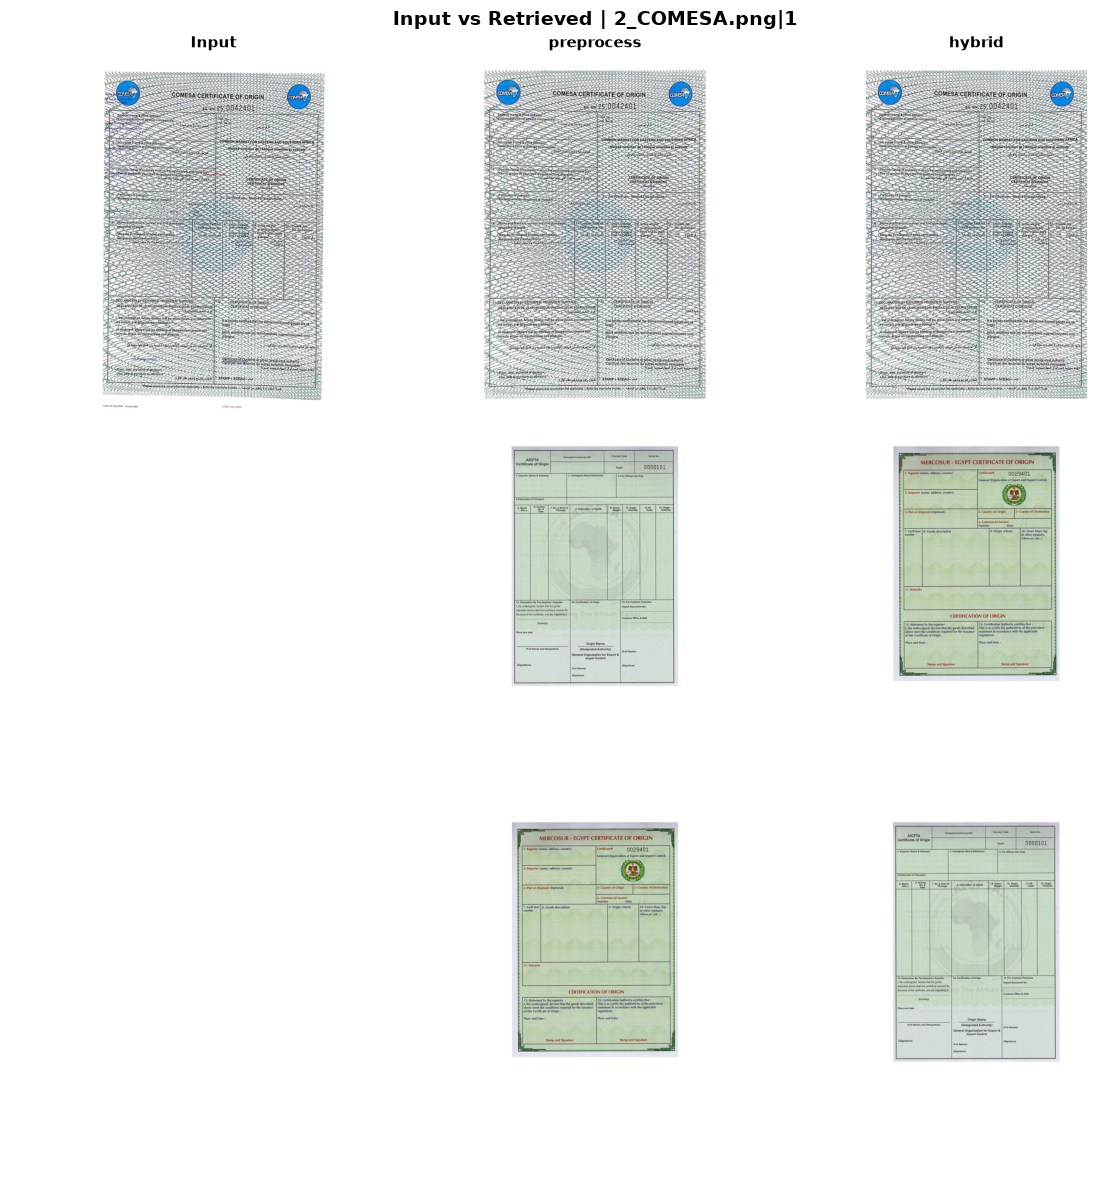

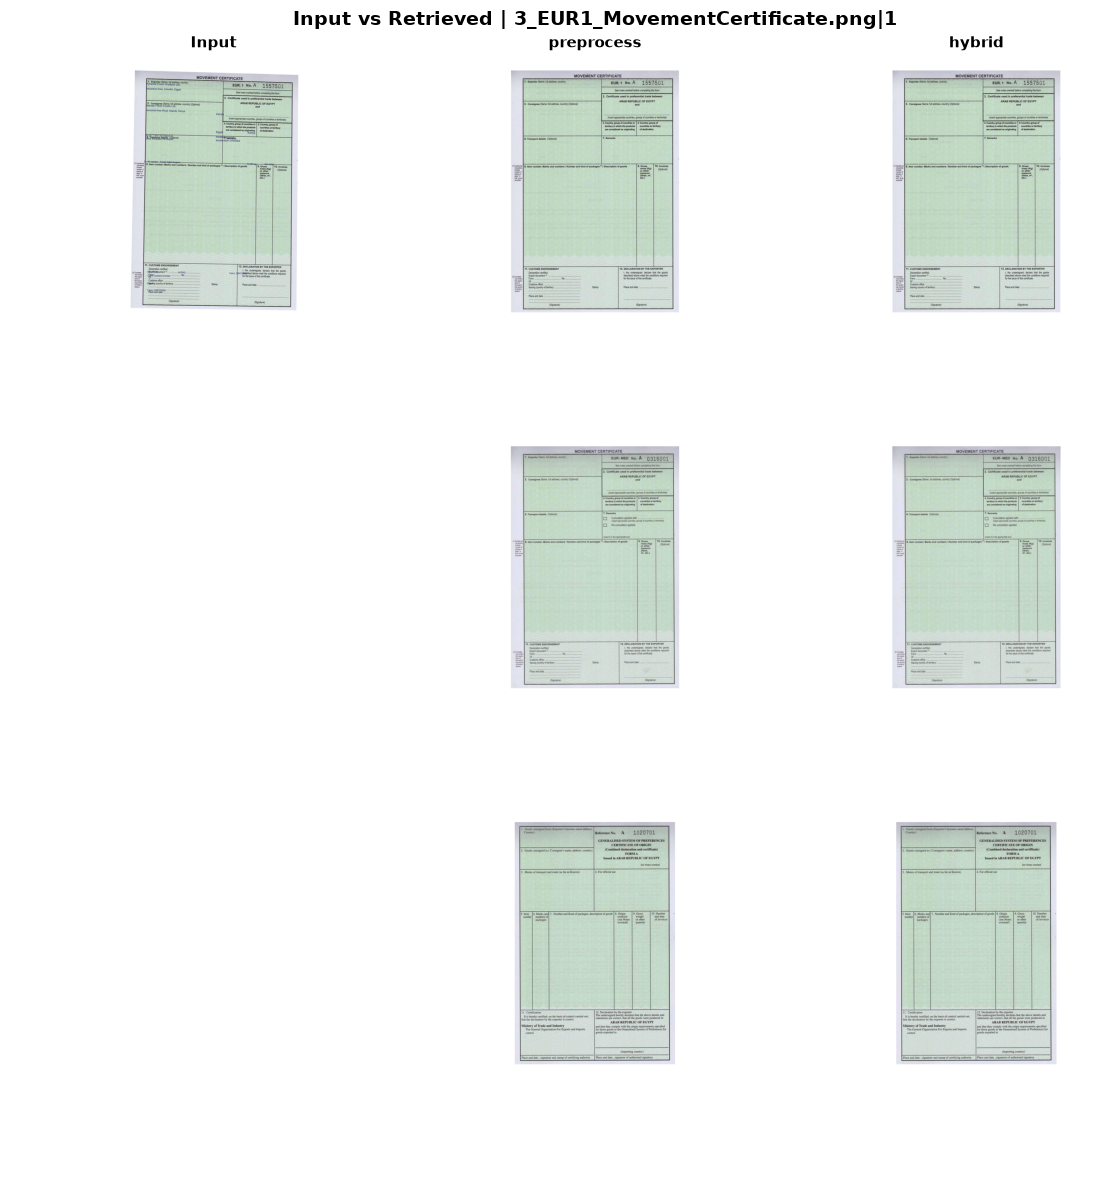

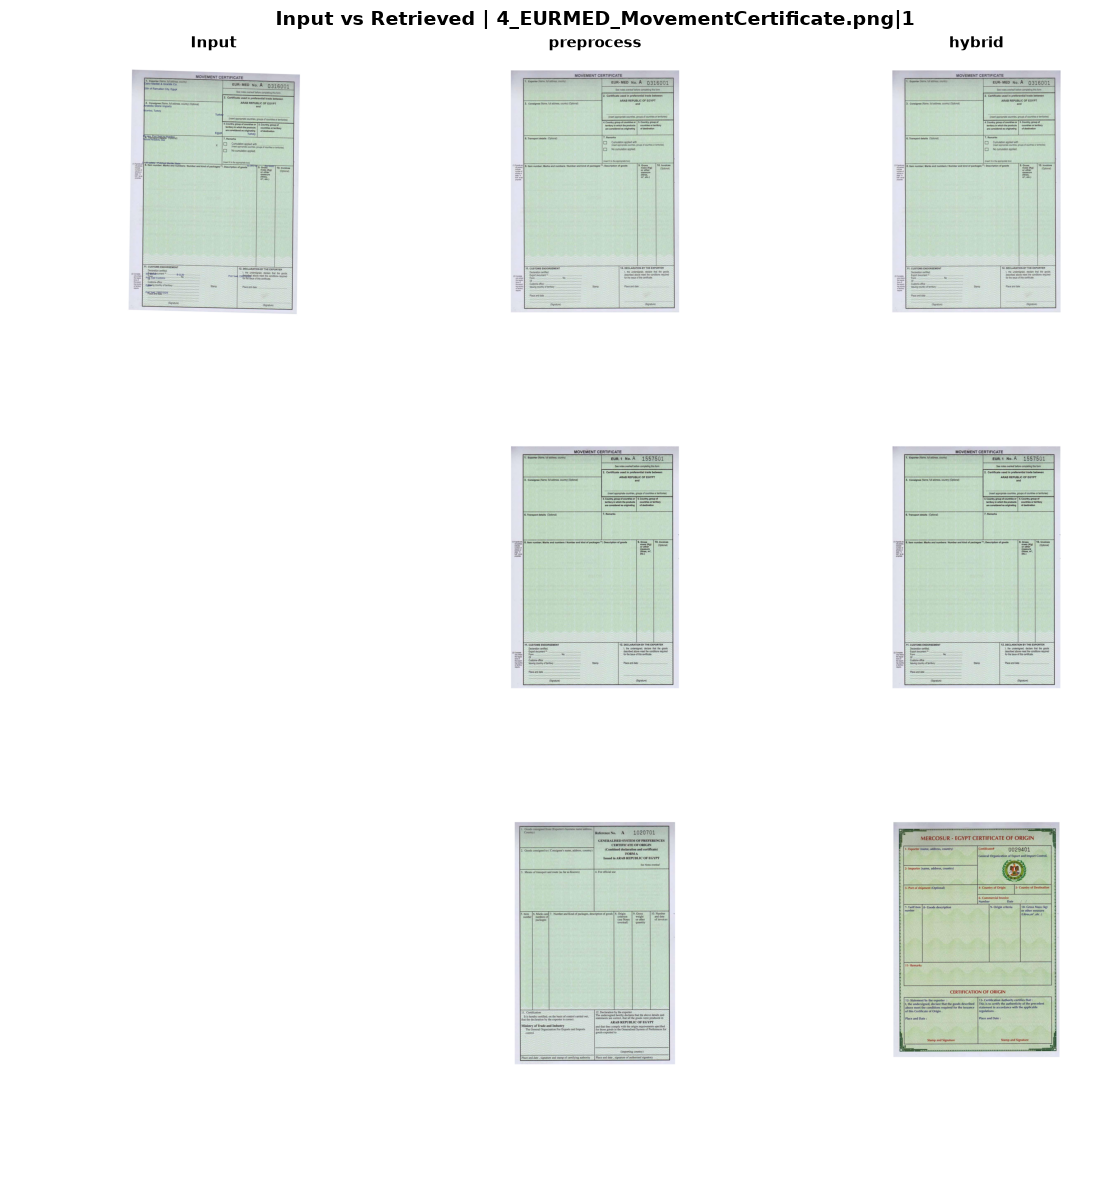

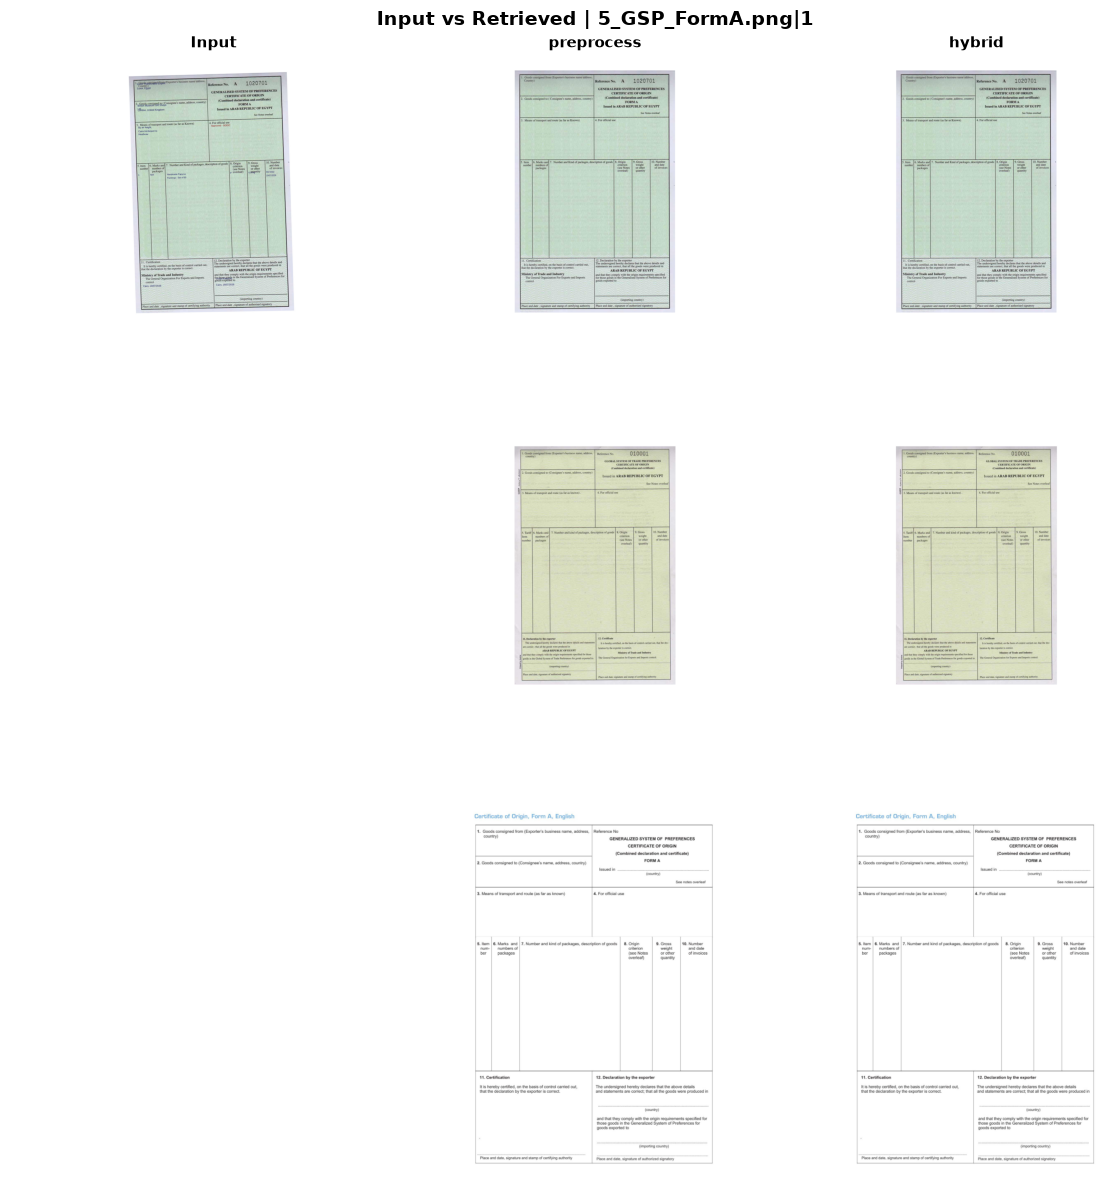

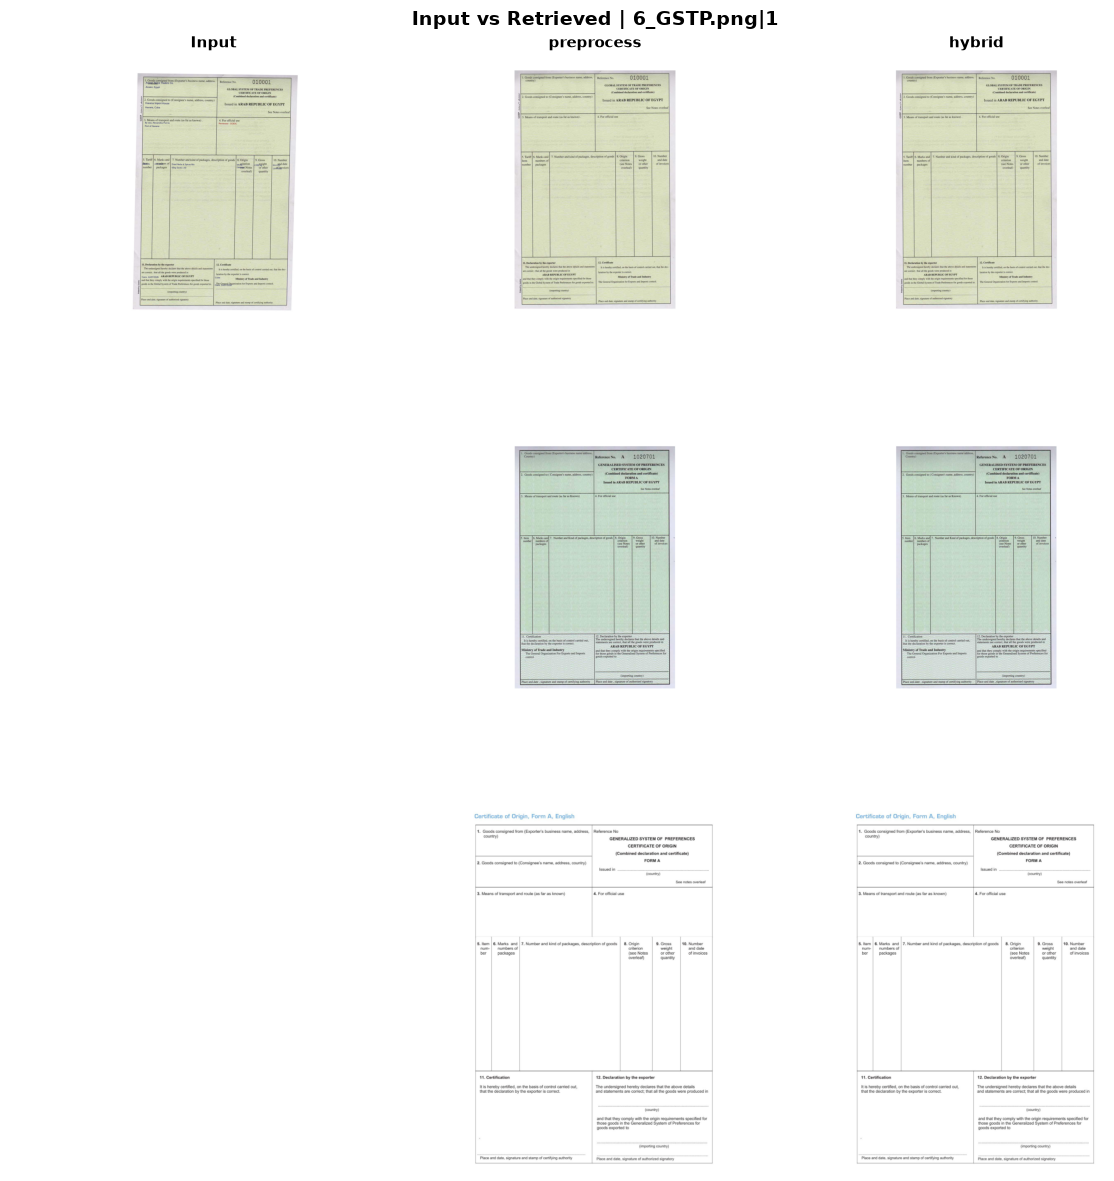

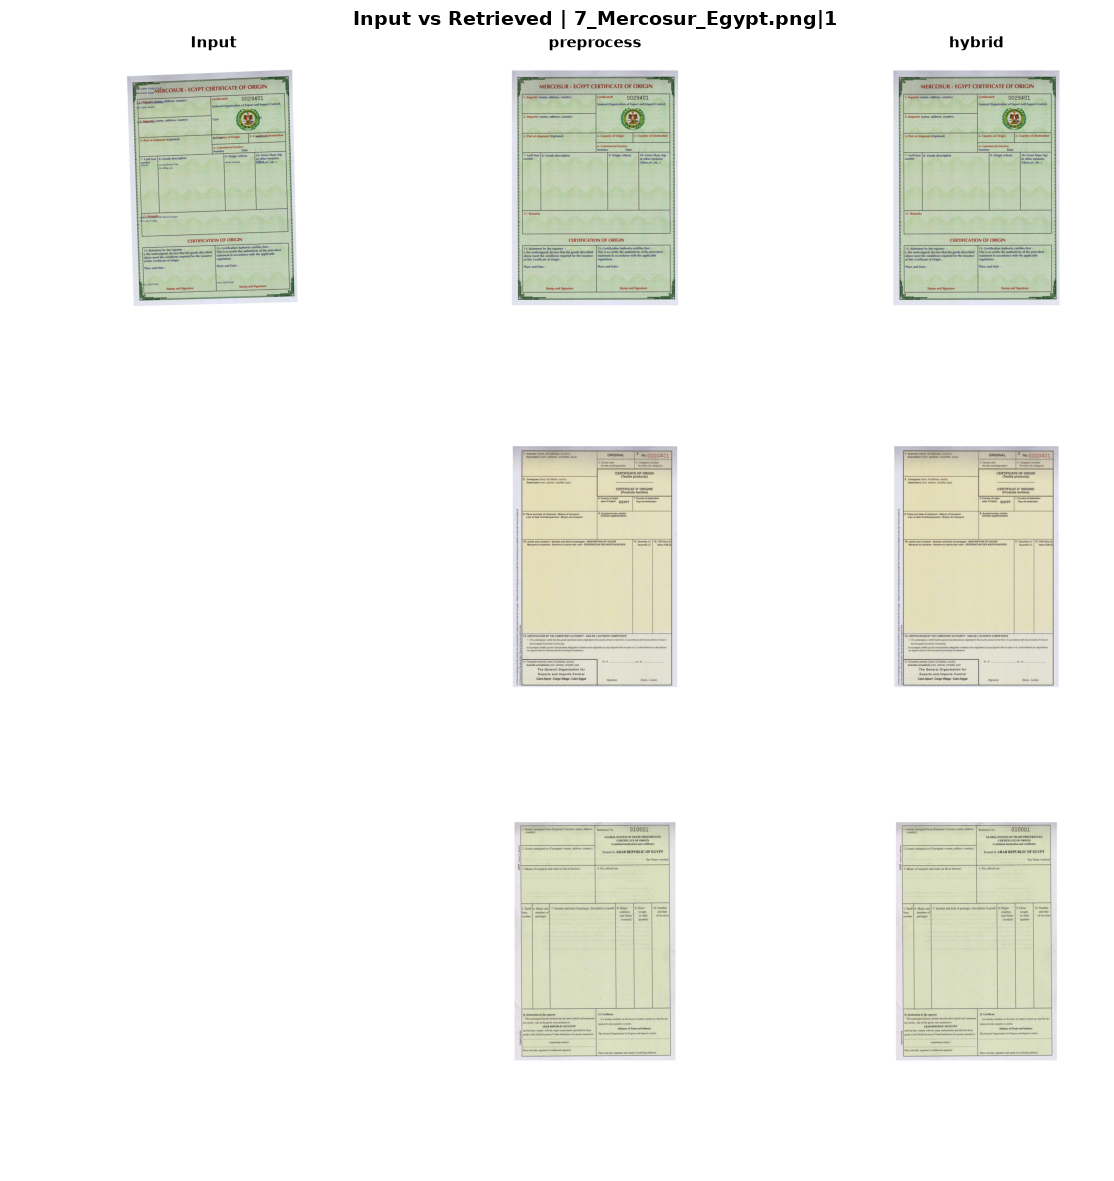

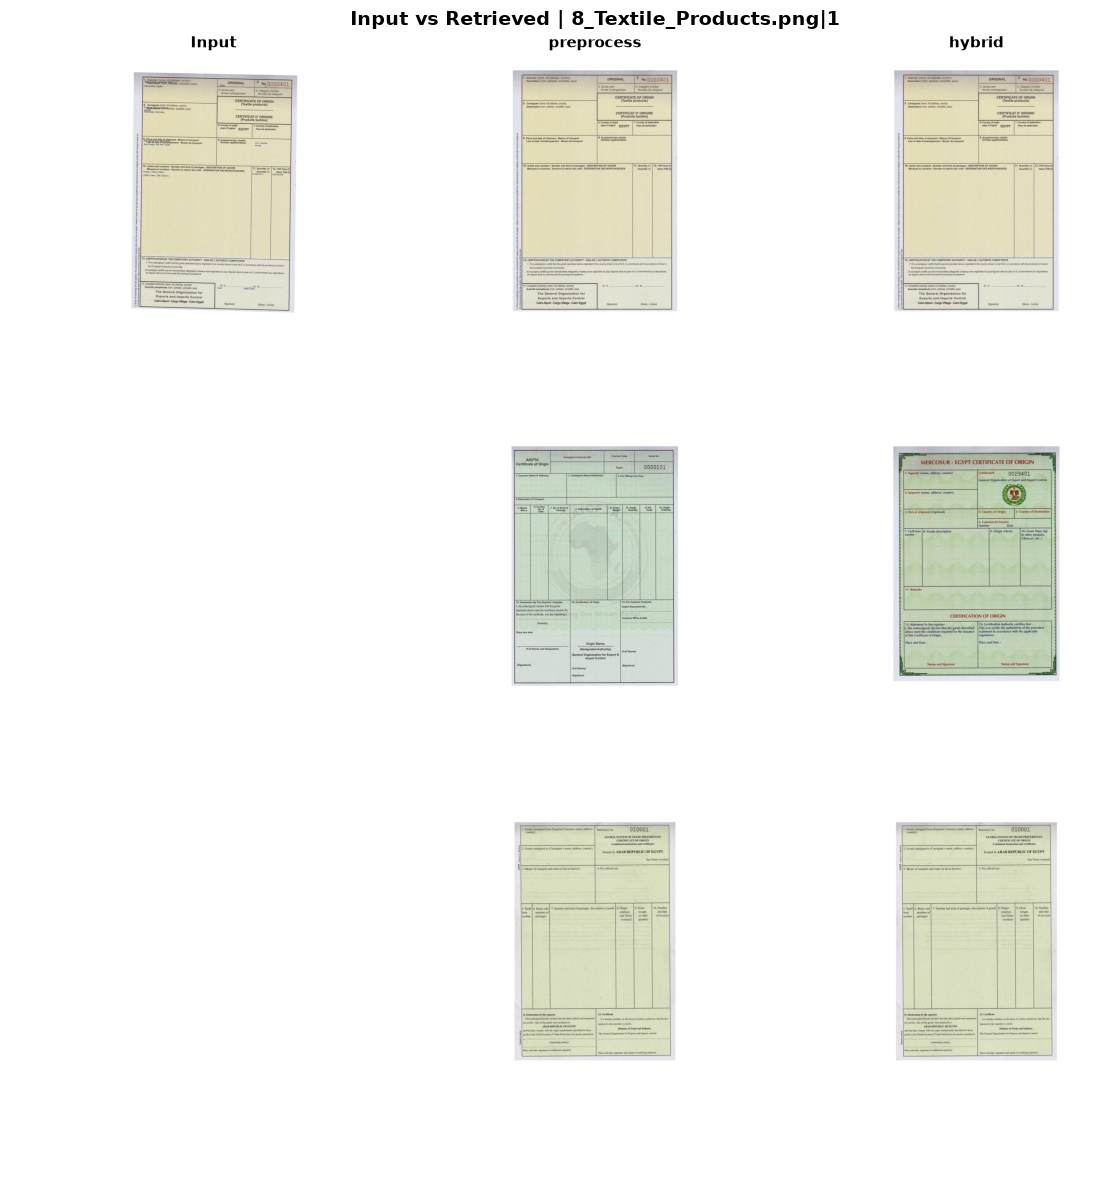

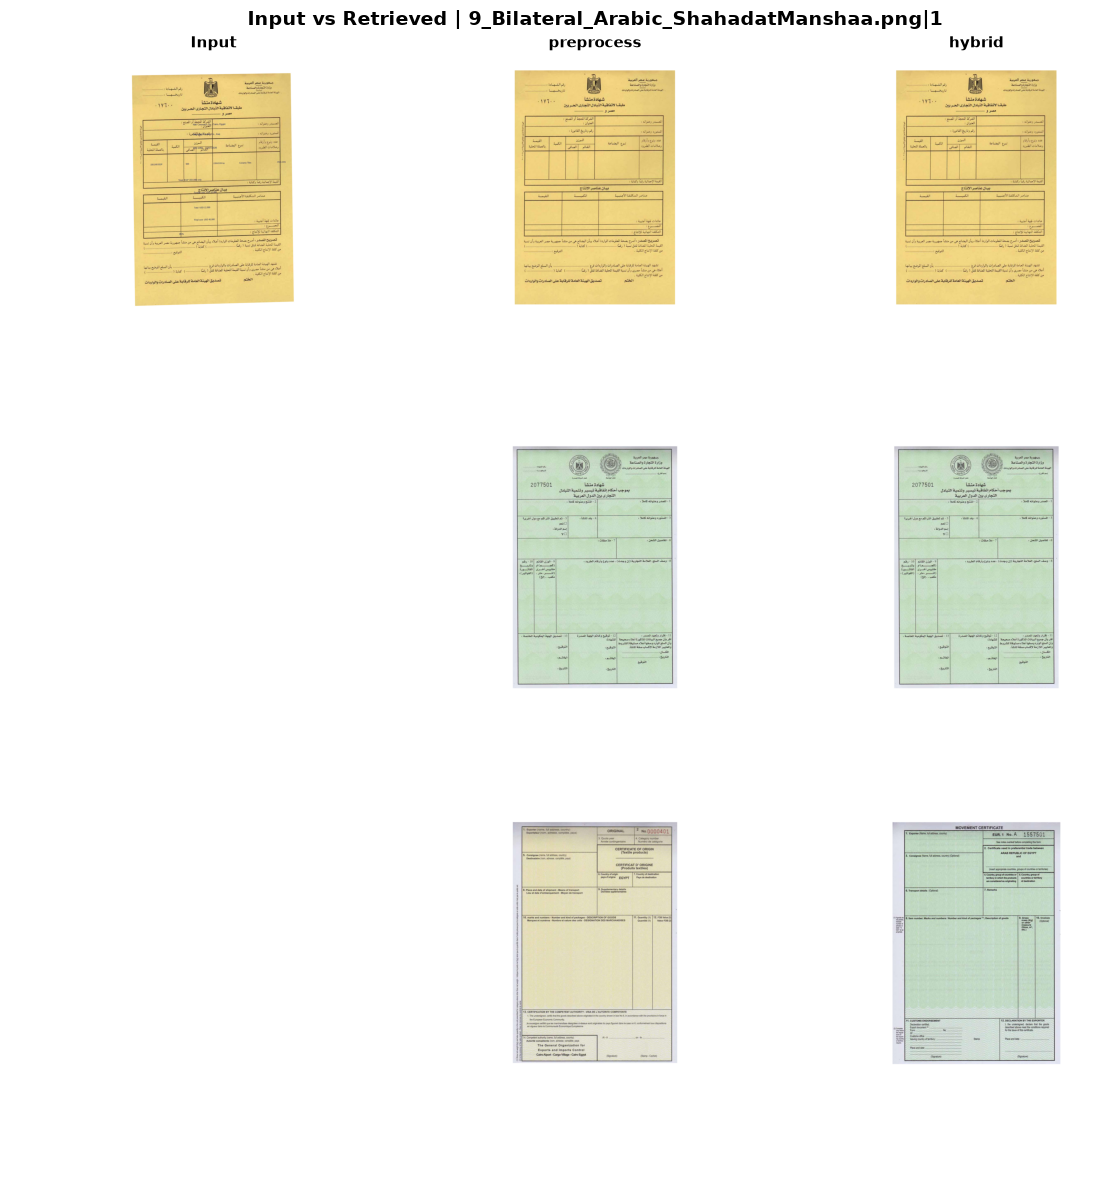

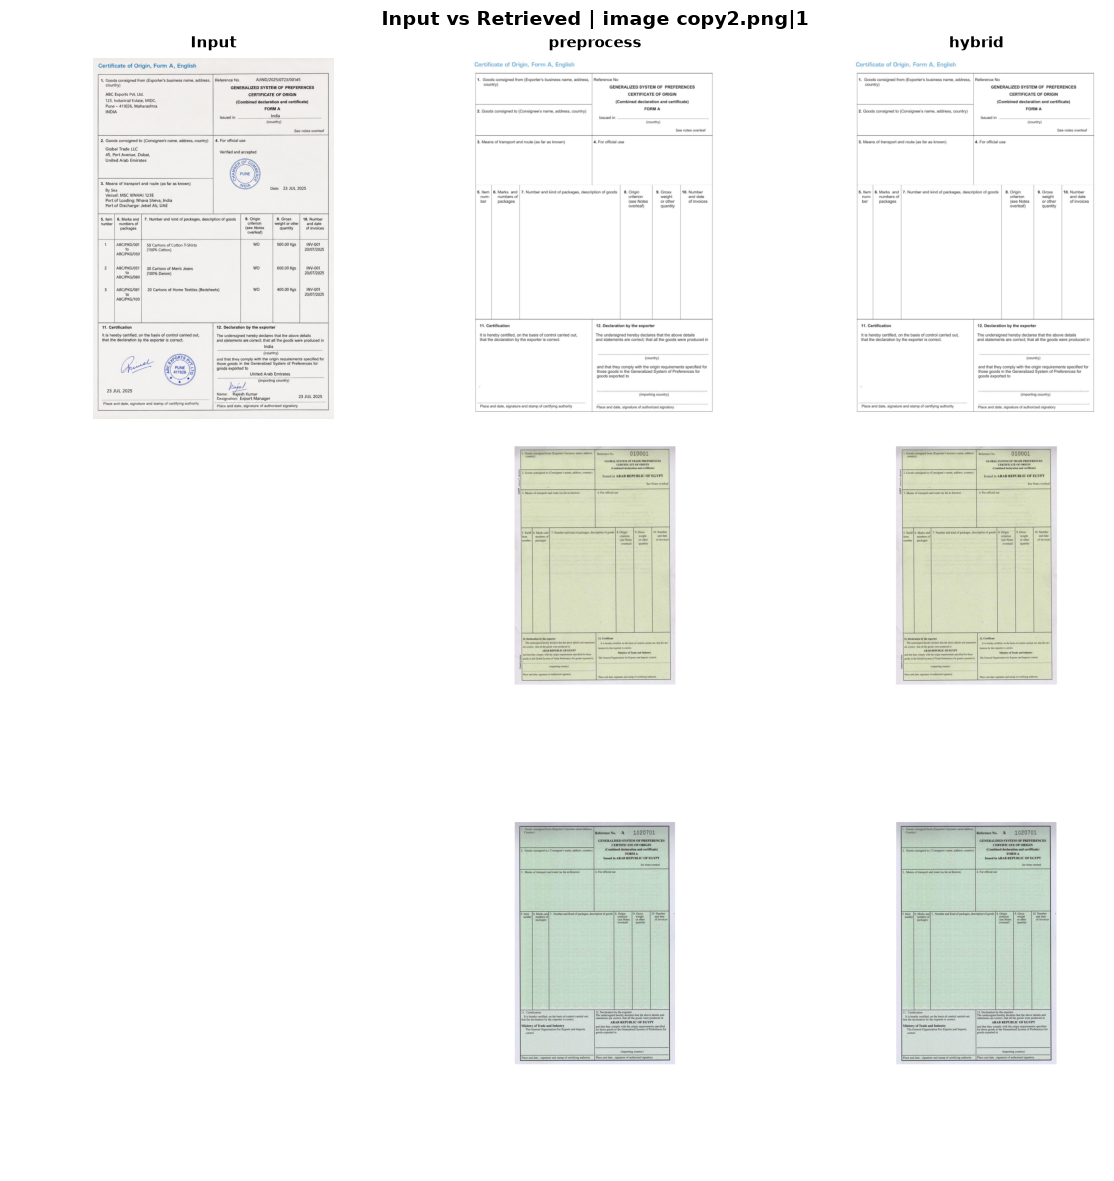

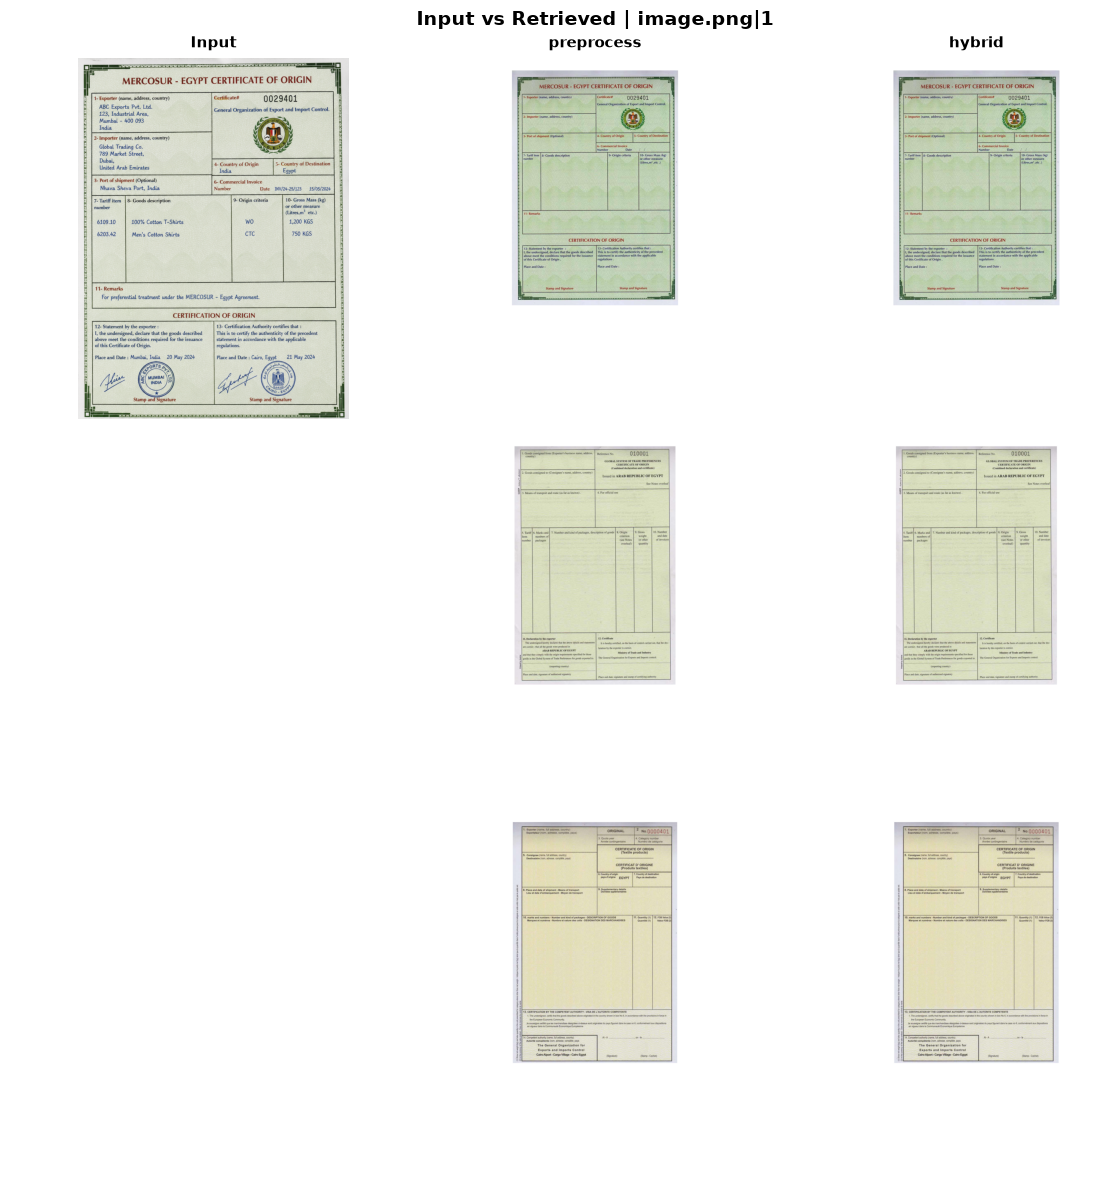

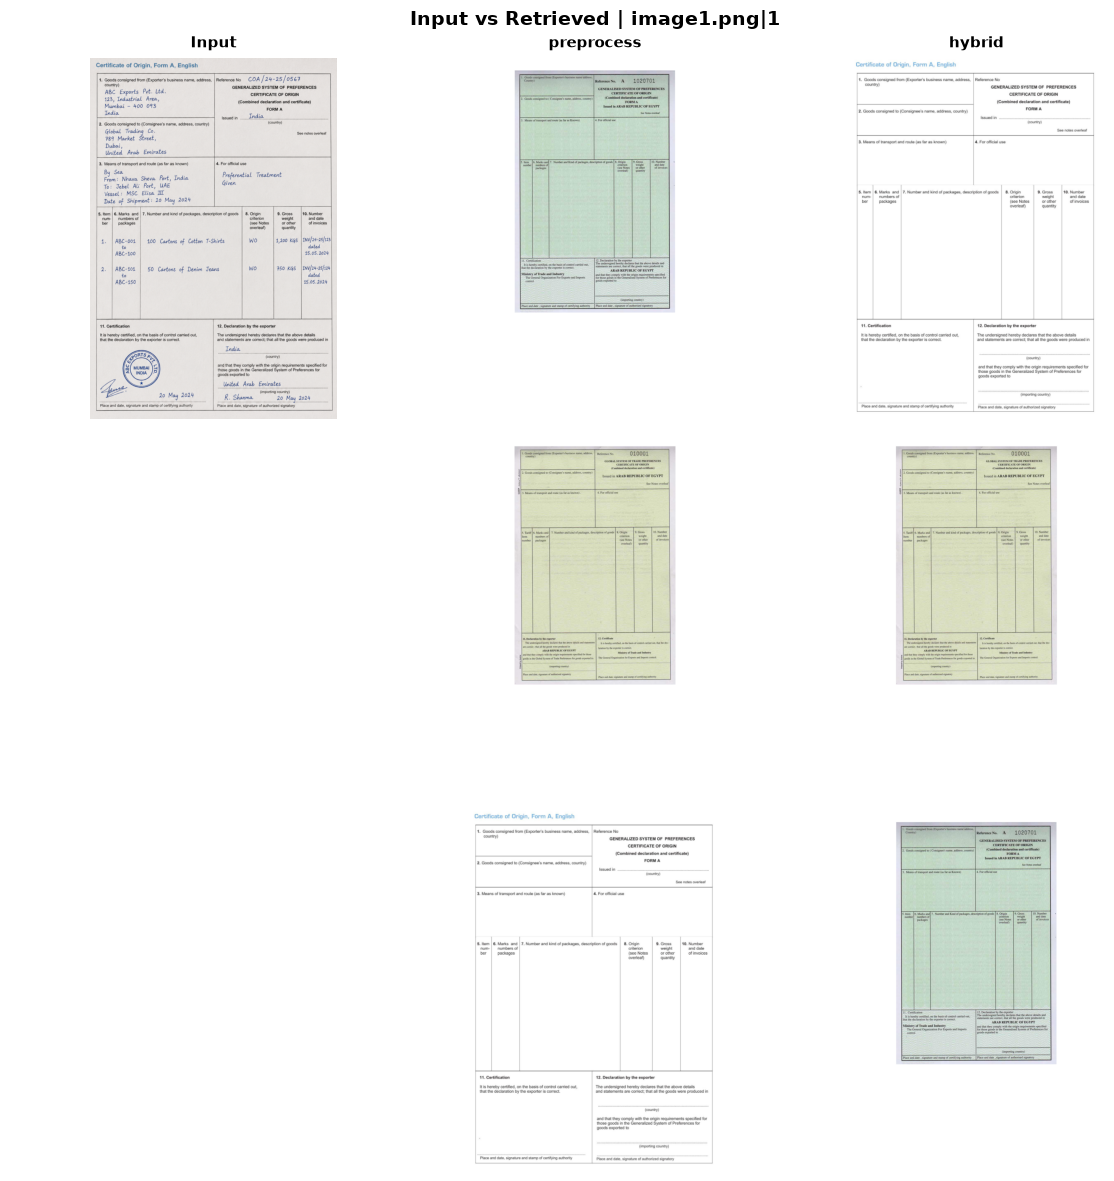

Done: Qwen preprocess and hybrid retrieval finished.


In [12]:
def retrieve_topk(query_id: str, mode: str, top_k: int = 3) -> List[Dict[str, Any]]:
    q_emb = mode_query_embeddings[mode][query_id]
    q_vec = q_emb.tolist()

    if mode == 'preprocess':
        db_result = pre_collection.query(
            query_embeddings=[q_vec],
            n_results=min(top_k, pre_collection.count())
        )

        ids = db_result.get('ids', [[]])[0]
        metas = db_result.get('metadatas', [[]])[0]
        dists = db_result.get('distances', [[]])[0]

        scored = []
        for rank, t_id in enumerate(ids):
            meta = metas[rank]
            image_sim = 1.0 - float(dists[rank])
            scored.append({
                'template_id': t_id,
                'file_name': meta['file_name'],
                'page_number': int(meta['page_number']),
                'similarity': float(image_sim),
                'image_similarity': float(image_sim),
            })

        scored.sort(key=lambda x: x['similarity'], reverse=True)
        return scored[:top_k]

    if mode == 'hybrid':
        scored = []
        for t_id, t_emb in mode_template_embeddings['hybrid'].items():
            image_sim = cosine_sim(q_emb, t_emb)
            txt_sim = text_similarity(query_texts.get(query_id, ''), template_texts.get(t_id, ''))
            final_sim = hybrid_alpha * image_sim + (1.0 - hybrid_alpha) * txt_sim

            t_meta = template_by_id[t_id]
            scored.append({
                'template_id': t_id,
                'file_name': t_meta['file_name'],
                'page_number': t_meta['page_number'],
                'similarity': float(final_sim),
                'image_similarity': float(image_sim),
            })

        scored.sort(key=lambda x: x['similarity'], reverse=True)
        return scored[:top_k]

    raise ValueError(f'Unsupported mode: {mode}')

results = {}
for q in query_records:
    q_id = q['id']
    results[q_id] = {
        'query': q,
        'preprocess': retrieve_topk(q_id, 'preprocess', top_k=top_k),
        'hybrid': retrieve_topk(q_id, 'hybrid', top_k=top_k),
    }

for q_id, payload in results.items():
    q = payload['query']
    q_key = f"{q['file_name']}|{q['page_number']}"
    print('=' * 100)
    print(f'Query: {q_key}')
    for mode in modes:
        top = payload[mode]
        for rank, item in enumerate(top, start=1):
            print(f"  {mode:<10} -> top{rank}: {item['file_name']}|{item['page_number']} | sim={item['similarity']:.4f}")

def show_results(query_record: Dict[str, Any], payload: Dict[str, Any]) -> None:
    n_results = max(len(payload[mode]) for mode in modes)
    cols = 1 + len(modes)
    rows = n_results
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))

    # Ensure axes is always 2D
    if rows == 1:
        axes = [axes]

    query_key = f"{query_record['file_name']}|{query_record['page_number']}"
    fig.suptitle(f'Input vs Retrieved | {query_key}', fontsize=14, fontweight='bold')

    # Column headers
    for col_idx, label in enumerate(['Input'] + modes):
        axes[0][col_idx].set_title(label, fontsize=11, fontweight='bold', pad=8)

    # Query image only in row 0, first column; hide others
    axes[0][0].imshow(query_record['image'])
    axes[0][0].set_xlabel(query_key, fontsize=8)
    axes[0][0].axis('off')
    for row_idx in range(1, rows):
        axes[row_idx][0].axis('off')

    # Fill retrieved results
    for col_offset, mode in enumerate(modes, start=1):
        preds = payload[mode]
        for row_idx in range(rows):
            ax = axes[row_idx][col_offset]
            if row_idx < len(preds):
                item = preds[row_idx]
                top_record = next(
                    (r for r in template_records if r['file_name'] == item['file_name'] and r['page_number'] == item['page_number']),
                    None,
                )
                if top_record is not None:
                    ax.imshow(top_record['image'])
                    ax.set_xlabel(
                        f"top{row_idx + 1}: {item['file_name']}|{item['page_number']}\nsim: {item['similarity']:.4f}",
                        fontsize=8
                    )
                else:
                    ax.text(0.5, 0.5, 'Image missing', ha='center', va='center')
            else:
                ax.text(0.5, 0.5, '—', ha='center', va='center', fontsize=14)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

for q_id, payload in results.items():
    show_results(payload['query'], payload)

print('Done: Qwen preprocess and hybrid retrieval finished.')


In [6]:
# Text-only retrieval from ChromaDB using OCR-extracted query text
# This uses Qwen text embeddings and searches the hybrid image collection.

text_top_k = 3
text_retrieval_results = {}

print('=' * 60)
print('Text retrieval from ChromaDB (OCR query text -> hybrid collection)')
print('=' * 60)

for q in query_records:
    q_id = q['id']
    q_text = query_texts.get(q_id, '').strip()

    if not q_text:
        text_retrieval_results[q_id] = []
        print(f"\nQuery {q['file_name']}|{q['page_number']} has empty OCR text; skipped.")
        continue

    q_text_vec = np.asarray(qwen_model.encode(q_text)).tolist()

    db_result = hyb_collection.query(
        query_embeddings=[q_text_vec],
        n_results=min(text_top_k, hyb_collection.count())
    )

    ids = db_result.get('ids', [[]])[0]
    metas = db_result.get('metadatas', [[]])[0]
    dists = db_result.get('distances', [[]])[0]

    ranked = []
    for i, t_id in enumerate(ids):
        meta = metas[i]
        sim = 1.0 - float(dists[i])
        ranked.append({
            'template_id': t_id,
            'file_name': meta['file_name'],
            'page_number': int(meta['page_number']),
            'similarity': float(sim),
        })

    text_retrieval_results[q_id] = ranked

    print(f"\nQuery: {q['file_name']}|{q['page_number']}")
    print(f"OCR text preview: {q_text[:120]}...")
    for rank, item in enumerate(ranked, start=1):
        print(
            f"  text_top{rank}: {item['file_name']}|{item['page_number']} | sim={item['similarity']:.4f}"
        )

print('\nDone: text retrieval from ChromaDB completed.')

Text retrieval from ChromaDB (OCR query text -> hybrid collection)

Query: 10_GAFTA_Arabic.png|1
OCR text preview: 2 Same as exporter 2 Cairo Fumiture Co., Egypt Egypt -4 Amman Home Fumishings ω Y NIA - 7 By land via Nuweiba- Aqaba INV...
  text_top1: Egypt- CoO Templates.pdf|8 | sim=0.3559
  text_top2: Egypt- CoO Templates.pdf|6 | sim=0.3150
  text_top3: Egypt- CoO Templates.pdf|2 | sim=0.3087

Query: 1_AfCFTA.png|1
OCR text preview: By sea, Container MSKU7823456, Vessel MSC Alexandra. ETD Alexandria Port 03/08262aticulars of Transport 5. Marks 6. Invo...
  text_top1: Egypt- CoO Templates.pdf|8 | sim=0.5068
  text_top2: Egypt- CoO Templates.pdf|6 | sim=0.4613
  text_top3: Egypt- CoO Templates.pdf|5 | sim=0.4420

Query: 2_COMESA.png|1
OCR text preview: ya Building- Supplies Lt...
  text_top1: Egypt- CoO Templates.pdf|10 | sim=0.1685
  text_top2: Egypt- CoO Templates.pdf|8 | sim=0.1510
  text_top3: CoO WCO (kyoto).png|1 | sim=0.1458

Query: 3_EUR1_MovementCertificate.png|1
OCR text prev

## Notes

- This notebook focuses only on Qwen preprocess and Qwen hybrid retrieval.
- If you want, you can later add a strict ground-truth Recall@2 map.
- The hybrid mode uses OCR text when available, and falls back to lexical overlap if needed.